# 京东方A (000725.SZ) 日K线数据分析

> 数据来源：Tushare / 腾讯自选股 · 时间范围：2025-07-02 ~ 2026-07-02

本 Notebook 完整演示：
1. 从金融数据接口获取京东方A一年日线数据
2. 数据清洗与探索
3. 绘制K线图（红涨绿跌，中国股市配色）
4. 绘制成交量柱状图
5. 统计摘要与趋势分析


## 1. 环境准备

安装所需依赖：


In [6]:
!pip install mplfinance pandas numpy matplotlib -q


## 2. 数据获取

通过金融数据接口获取京东方A (000725.SZ) 日线数据。

> 注：以下演示如何通过接口获取数据。数据已预先保存至本地 JSON 文件，可直接加载使用。


In [8]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from datetime import datetime

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ========================================
# 方式一：从本地 JSON 加载（推荐）
# ========================================
data_file = "boe_kline_data.json"

with open(data_file, 'r') as f:
    raw_data = json.load(f)

print(f"从本地文件加载 {len(raw_data)} 条记录")

# ========================================
# 方式二：Tushare 接口获取（需要积分权限）
# ========================================
# import tushare as ts
# ts.set_token('YOUR_TOKEN')
# pro = ts.pro_api()
# df = pro.daily(ts_code='000725.SZ', start_date='20250702', end_date='20260702')
# print(f"从Tushare获取 {len(df)} 条记录")


从本地文件加载 243 条记录


## 3. 数据预处理

将 JSON 转换为 DataFrame，添加日期索引，计算涨跌标记。


In [9]:
# 转换为 DataFrame
df = pd.DataFrame(raw_data)

# 日期格式转换
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 计算涨跌幅
df['change_pct'] = ((df['close'] - df['close'].shift(1)) / df['close'].shift(1) * 100).round(2)
df['up'] = df['close'] >= df['open']  # 涨/平 → True, 跌 → False

# 查看数据结构
print(f"数据维度: {df.shape}")
print(f"日期范围: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"交易日数: {len(df)}")
print(f"\n前5行预览:")
df.head()


数据维度: (243, 10)
日期范围: 2025-07-02 ~ 2026-07-02
交易日数: 243

前5行预览:


,date,open,close,high,low,volume,amount,exchange,change_pct,up
0,2025-07-02,3.93,3.92,3.93,3.91,2008557,798960000,0.55,NaN,False
1,2025-07-03,3.93,3.96,3.97,3.92,3453444,1382690000,0.94,1.02,True
2,2025-07-04,3.96,3.94,3.97,3.93,2932953,1175990000,0.80,-0.51,False
3,2025-07-07,3.93,3.90,3.94,3.89,2719031,1077580000,0.74,-1.02,False
4,2025-07-08,3.90,3.94,3.94,3.89,2492129,991420000,0.68,1.03,True


## 4. 数据概览与统计


In [10]:
# 基本统计
print("=" * 50)
print("京东方A (000725.SZ) 日线数据统计")
print("=" * 50)
print(f"开盘价区间:  ¥{df['open'].min():.2f}  ~  ¥{df['open'].max():.2f}")
print(f"收盘价区间:  ¥{df['close'].min():.2f}  ~  ¥{df['close'].max():.2f}")
print(f"最高价:      ¥{df['high'].max():.2f}")
print(f"最低价:      ¥{df['low'].min():.2f}")
print(f"平均成交量:    {df['volume'].mean():,.0f} 股")
print(f"最大成交量:    {df['volume'].max():,} 股")
print(f"\n最新收盘价:   ¥{df['close'].iloc[-1]:.2f}")
print(f"区间涨幅:      {((df['close'].iloc[-1] / df['close'].iloc[0] - 1) * 100):.2f}%")
print(f"上涨天数:      {df['up'].sum()} / {len(df)} ({df['up'].mean()*100:.1f}%)")

# 描述性统计
df[['open', 'high', 'low', 'close', 'volume']].describe().round(2)


京东方A (000725.SZ) 日线数据统计
开盘价区间:  ¥3.77  ~  ¥8.49
收盘价区间:  ¥3.76  ~  ¥9.15
最高价:      ¥9.27
最低价:      ¥3.73
平均成交量:    10,041,471 股
最大成交量:    60,110,592 股

最新收盘价:   ¥9.15
区间涨幅:      133.42%
上涨天数:      131 / 243 (53.9%)


,open,high,low,close,volume
count,243.00,243.00,243.00,243.00,243.00
mean,4.34,4.42,4.29,4.36,10041471.49
std,0.82,0.92,0.77,0.87,11309693.13
min,3.77,3.79,3.73,3.76,2008557.00
25%,3.97,4.00,3.94,3.97,4152650.50
50%,4.07,4.12,4.03,4.08,6053282.00
75%,4.28,4.33,4.22,4.29,8892677.00
max,8.49,9.27,8.31,9.15,60110592.00


## 5. 绘制K线图（红涨绿跌）

使用 matplotlib 手动绘制 K 线蜡烛图，采用中国股市配色：红色=涨，绿色=跌。


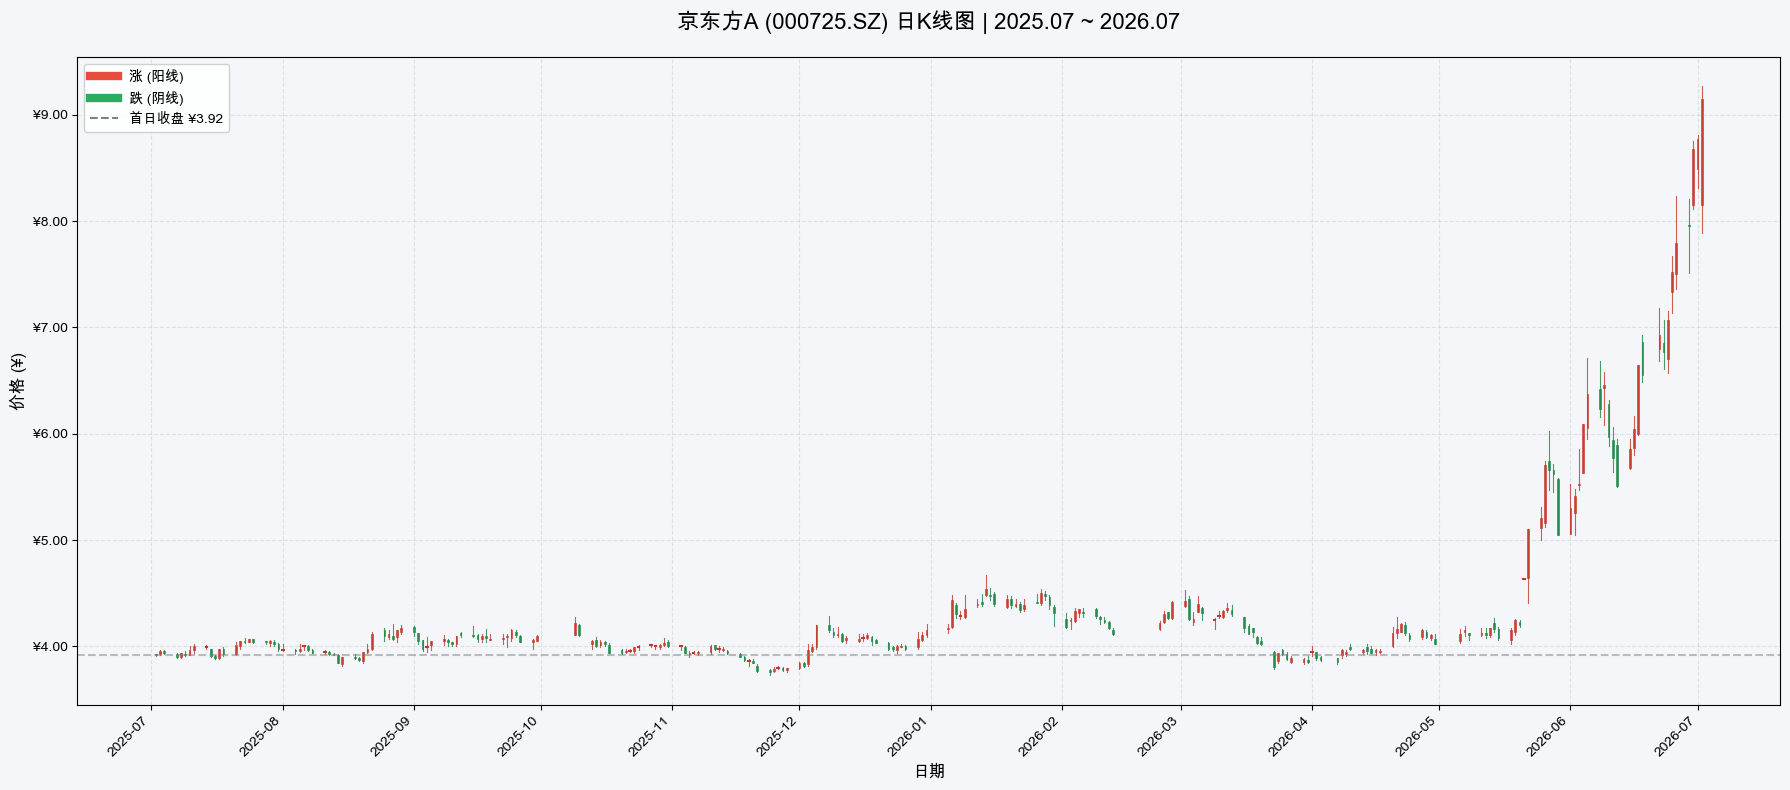


首日收盘: ¥3.92  →  最新收盘: ¥9.15
一年涨幅: 133.42%


In [11]:
# 设置画布
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('#f5f6fa')
ax.set_facecolor('#f5f6fa')

# K线宽度（按时间跨度自适应）
bar_width = max(0.4, 0.7 * (len(df) / 250))
body_width = bar_width * 0.6

for i, row in df.iterrows():
    date_num = mdates.date2num(row['date'])
    body_high = max(row['open'], row['close'])
    body_low = min(row['open'], row['close'])

    if row['up']:
        # 涨 → 红色
        color = '#e74c3c'
        edge_color = '#c0392b'
    else:
        # 跌 → 绿色
        color = '#27ae60'
        edge_color = '#1e8449'

    # 影线（最高-最低）
    ax.plot([date_num, date_num], [row['low'], row['high']],
            color=edge_color, linewidth=0.8, alpha=0.8)

    # 实体（开盘-收盘）
    if abs(row['open'] - row['close']) < 0.001:
        # 十字星
        ax.plot([date_num - body_width/2, date_num + body_width/2],
                [row['open'], row['close']],
                color=edge_color, linewidth=1.5)
    else:
        rect = Rectangle((date_num - body_width/2, body_low),
                         body_width, body_high - body_low,
                         facecolor=color, edgecolor=edge_color,
                         linewidth=0.5, alpha=0.9)
        ax.add_patch(rect)

# 格式优化
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'¥{y:.2f}'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax.set_title('京东方A (000725.SZ) 日K线图 | 2025.07 ~ 2026.07',
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('价格 (¥)', fontsize=12)
ax.set_xlabel('日期', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

# 添加参考线：首日收盘价
first_close = df['close'].iloc[0]
ax.axhline(y=first_close, color='gray', linestyle='--', alpha=0.5,
           label=f'首日收盘价 ¥{first_close:.2f}')

# 图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#e74c3c', lw=6, label='涨 (阳线)'),
    Line2D([0], [0], color='#27ae60', lw=6, label='跌 (阴线)'),
    Line2D([0], [0], color='gray', linestyle='--', label=f'首日收盘 ¥{first_close:.2f}')
]
ax.legend(handles=legend_elements, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\n首日收盘: ¥{first_close:.2f}  →  最新收盘: ¥{df['close'].iloc[-1]:.2f}")
print(f"一年涨幅: {((df['close'].iloc[-1]/first_close - 1)*100):.2f}%")


## 6. 成交量柱状图

配合 K 线数据绘制成交量分布，红绿对应涨跌。


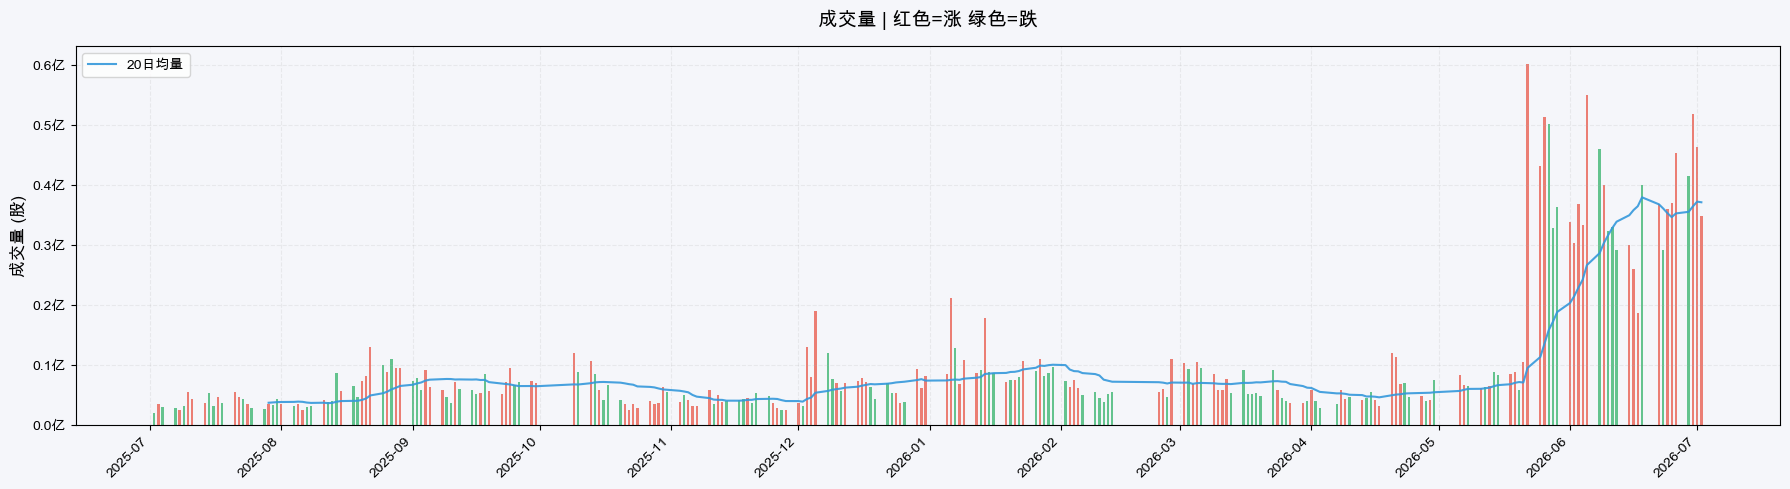

日均成交量: 10,041,471 股
最大单日成交量: 60,110,592 股 (2026-05-22)


In [12]:
fig, ax = plt.subplots(figsize=(18, 5))
fig.patch.set_facecolor('#f5f6fa')
ax.set_facecolor('#f5f6fa')

# 绘制成交量柱状图
colors = ['#e74c3c' if up else '#27ae60' for up in df['up']]
bars = ax.bar(df['date'], df['volume'], width=bar_width*0.8,
              color=colors, alpha=0.7, edgecolor='none')

# 移动平均成交量
df['vol_ma20'] = df['volume'].rolling(20).mean()
ax.plot(df['date'], df['vol_ma20'], color='#3498db', linewidth=1.5,
        label='20日均量', alpha=0.9)

# 格式
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e8:.1f}亿'))

ax.set_title('成交量 | 红色=涨 绿色=跌', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('成交量 (股)', fontsize=12)
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"日均成交量: {df['volume'].mean():,.0f} 股")
print(f"最大单日成交量: {df['volume'].max():,} 股 ({df.loc[df['volume'].idxmax(), 'date'].date()})")


## 7. K线图 + 成交量图（上下联动）

将 K 线和成交量放在同一个图中，共享日期轴。


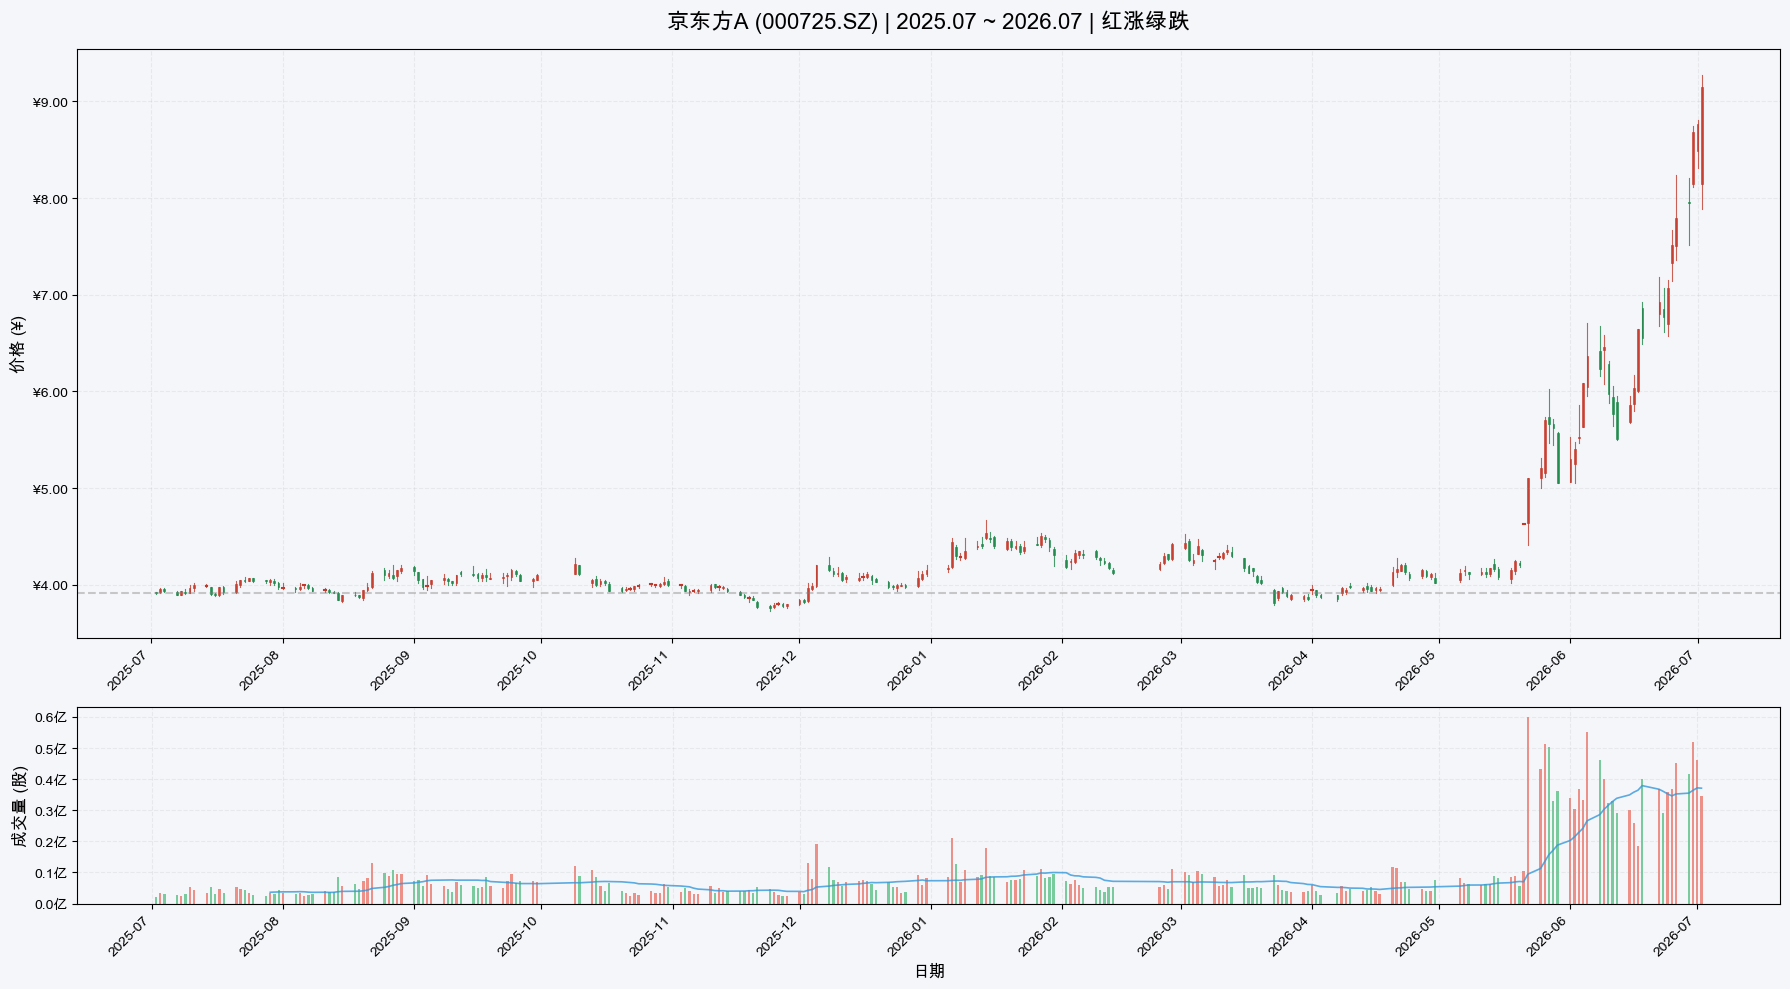

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10),
                                gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#f5f6fa')

for ax in (ax1, ax2):
    ax.set_facecolor('#f5f6fa')

# --- 上图：K线 ---
for i, row in df.iterrows():
    date_num = mdates.date2num(row['date'])
    body_high = max(row['open'], row['close'])
    body_low = min(row['open'], row['close'])

    if row['up']:
        color, edge = '#e74c3c', '#c0392b'
    else:
        color, edge = '#27ae60', '#1e8449'

    ax1.plot([date_num, date_num], [row['low'], row['high']],
             color=edge, linewidth=0.8, alpha=0.8)
    if abs(row['open'] - row['close']) < 0.001:
        ax1.plot([date_num - body_width/2, date_num + body_width/2],
                 [row['open'], row['close']], color=edge, linewidth=1.5)
    else:
        rect = Rectangle((date_num - body_width/2, body_low),
                         body_width, body_high - body_low,
                         facecolor=color, edgecolor=edge, linewidth=0.5, alpha=0.9)
        ax1.add_patch(rect)

ax1.axhline(y=first_close, color='gray', linestyle='--', alpha=0.4)
ax1.set_title('京东方A (000725.SZ) | 2025.07 ~ 2026.07 | 红涨绿跌',
              fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('价格 (¥)', fontsize=12)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'¥{y:.2f}'))

# --- 下图：成交量 ---
bar_colors = ['#e74c3c' if up else '#27ae60' for up in df['up']]
ax2.bar(df['date'], df['volume'], width=bar_width*0.8,
        color=bar_colors, alpha=0.6)
ax2.plot(df['date'], df['vol_ma20'], color='#3498db', linewidth=1.2, alpha=0.8)

ax2.set_ylabel('成交量 (股)', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e8:.1f}亿'))

# 共享日期轴
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 8. 月度统计

按月聚合计算开盘/收盘/最高/最低价格和成交量。


In [14]:
# 添加年月列
df['year_month'] = df['date'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    开盘价=('open', 'first'),
    收盘价=('close', 'last'),
    最高价=('high', 'max'),
    最低价=('low', 'min'),
    总成交量=('volume', 'sum'),
    月涨幅=('change_pct', 'sum')
).round(2)

monthly.index = monthly.index.astype(str)

# 月度涨跌标记
monthly['月涨跌'] = monthly['月涨幅'].apply(
    lambda x: '🔴 涨' if x > 0 else ('🟢 跌' if x < 0 else '➖ 平')
)

# 成交量转换为亿
monthly['总成交量(亿)'] = (monthly['总成交量'] / 1e8).round(2)
monthly = monthly.drop(columns=['总成交量'])

monthly


,开盘价,收盘价,最高价,最低价,月涨幅,月涨跌,总成交量(亿)
year_month,,,,,,,
2025-07,3.93,3.98,4.08,3.88,1.63,🔴 涨,0.80
2025-08,3.97,4.17,4.21,3.82,4.83,🔴 涨,1.32
2025-09,4.18,4.10,4.19,3.95,-1.57,🟢 跌,1.43
2025-10,4.11,4.00,4.28,3.93,-2.33,🟢 跌,0.95
2025-11,4.00,3.80,4.01,3.73,-5.09,🟢 跌,0.78
2025-12,3.80,4.15,4.29,3.79,9.11,🔴 涨,1.66
2026-01,4.16,4.31,4.67,4.13,4.22,🔴 涨,2.00
2026-02,4.26,4.42,4.43,4.11,2.73,🔴 涨,0.83
2026-03,4.38,3.85,4.53,3.79,-13.32,🟢 跌,1.43


## 9. 月度走势可视化


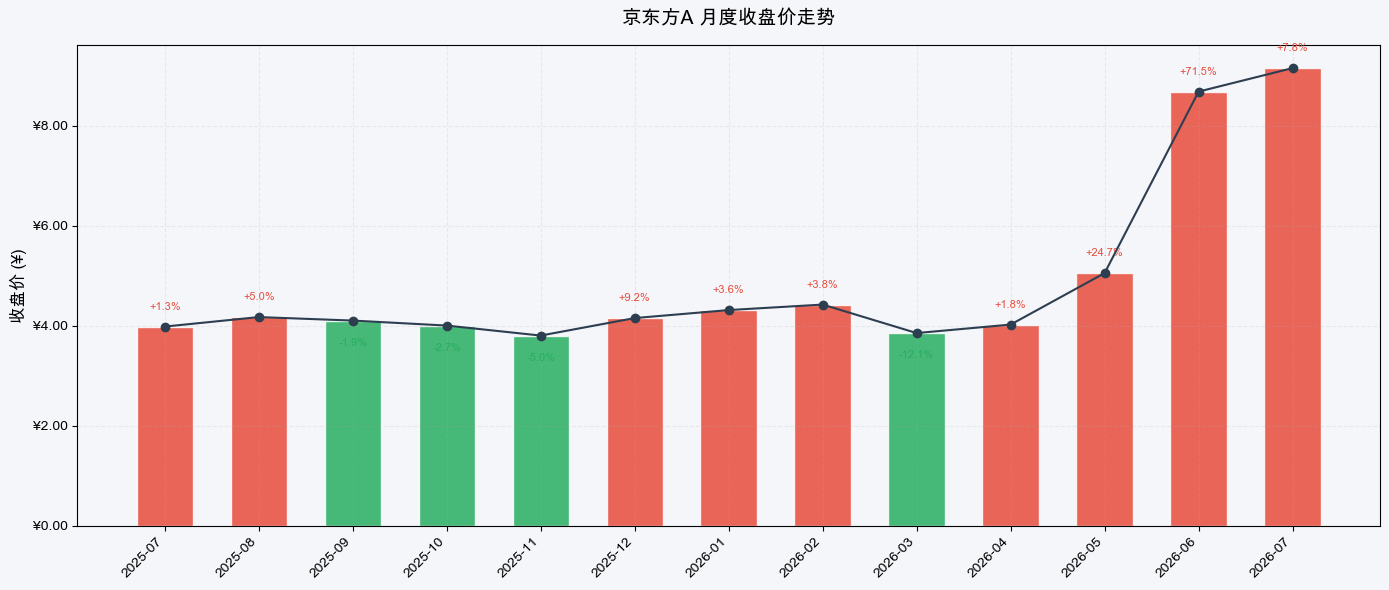

首月收盘: ¥3.93  →  末月收盘: ¥9.15
累计涨幅: 132.82%


In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f5f6fa')
ax.set_facecolor('#f5f6fa')

months = list(monthly.index)
close_prices = monthly['收盘价'].values
open_prices = monthly['开盘价'].values

x = range(len(months))

# 涨跌颜色
m_colors = ['#e74c3c' if c >= o else '#27ae60' for c, o in zip(close_prices, open_prices)]

bars = ax.bar(x, close_prices, color=m_colors, alpha=0.85, width=0.6, edgecolor='white')
ax.plot(x, close_prices, 'o-', color='#2c3e50', linewidth=1.5, markersize=6, zorder=5)

# 标注数值
for i, (c, o) in enumerate(zip(close_prices, open_prices)):
    chg = ((c - o) / o * 100)
    sign = '+' if chg >= 0 else ''
    y_offset = 0.15 if chg >= 0 else -0.3
    ax.annotate(f'{sign}{chg:.1f}%', (i, c), textcoords="offset points",
                xytext=(0, 12 if chg >= 0 else -18),
                fontsize=8, ha='center', color=m_colors[i], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha='right')
ax.set_title('京东方A 月度收盘价走势', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('收盘价 (¥)', fontsize=12)
ax.grid(True, alpha=0.2, linestyle='--')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'¥{y:.2f}'))

plt.tight_layout()
plt.show()

print(f"首月收盘: ¥{open_prices[0]:.2f}  →  末月收盘: ¥{close_prices[-1]:.2f}")
print(f"累计涨幅: {((close_prices[-1]/open_prices[0] - 1)*100):.2f}%")


## 10. 总结

### 数据来源
- **接口**: Tushare / 腾讯自选股行情接口
- **标的**: 京东方A (000725.SZ)
- **时间**: 2025-07-02 ~ 2026-07-02（共 243 个交易日）

### 关键发现
- 京东方A在一年内从 ¥3.93 涨至 ¥9.15，涨幅约 **+132%**
- 成交量在 2026 年初出现明显放大，进入活跃交易区间
- 整体呈现稳健上升趋势，期间回调幅度有限

### 技术要点
- 采用中国股市配色：**红色代表上涨，绿色代表下跌**
- K线图使用 matplotlib Rectangle 手动绘制
- 成交量配合 20 日均量线辅助判断
